## Parte 3: Benchmarking de Técnicas de Machine Learning

1. Selección de Modelos:
* Entrenar y evaluar múltiples modelos de machine learning (por ejemplo,  Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost y LGBM).
* Utilizar validación cruzada para evaluar el rendimiento de los modelos.
2. Comparación de Modelos:
* Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
* Seleccionar el mejor modelo basado en las métricas obtenidas.

In [ ]:
# Evaluo varios modelos
modelos = {
    'Lineal':           make_pipeline(preprocesador, LinearRegression()),
    'Ridge':            make_pipeline(preprocesador, Ridge(alpha=1.0)),
    'Lasso':            make_pipeline(preprocesador, Lasso(alpha=0.1)),
    'KNN(k=10)':        make_pipeline(preprocesador, KNeighborsRegressor(n_neighbors=10, n_jobs=-1)),
    'Árbol(d=10)':      make_pipeline(preprocesador, DecisionTreeRegressor(max_depth=10, random_state=42)),
    'RandomForest(200)': make_pipeline(preprocesador, RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)),
    'GradientBoosting':  make_pipeline(preprocesador, GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)),
}

In [ ]:
# Medimos lso tiempos que toma y los resultados obtenidos
resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
GradientBoosting,1.0000,0.0000,0.0000,0.52,0.009
RandomForest(200),1.0000,0.0000,0.0000,0.65,0.062
Árbol(d=10),1.0000,0.0000,0.0000,0.01,0.006
Lasso,0.8552,175.3267,214.0178,0.01,0.006
Ridge,0.8550,175.1244,214.1269,0.01,0.008
Lineal,0.8549,175.4471,214.1990,0.02,0.006
KNN(k=10),0.2164,381.2700,497.8708,0.01,0.009


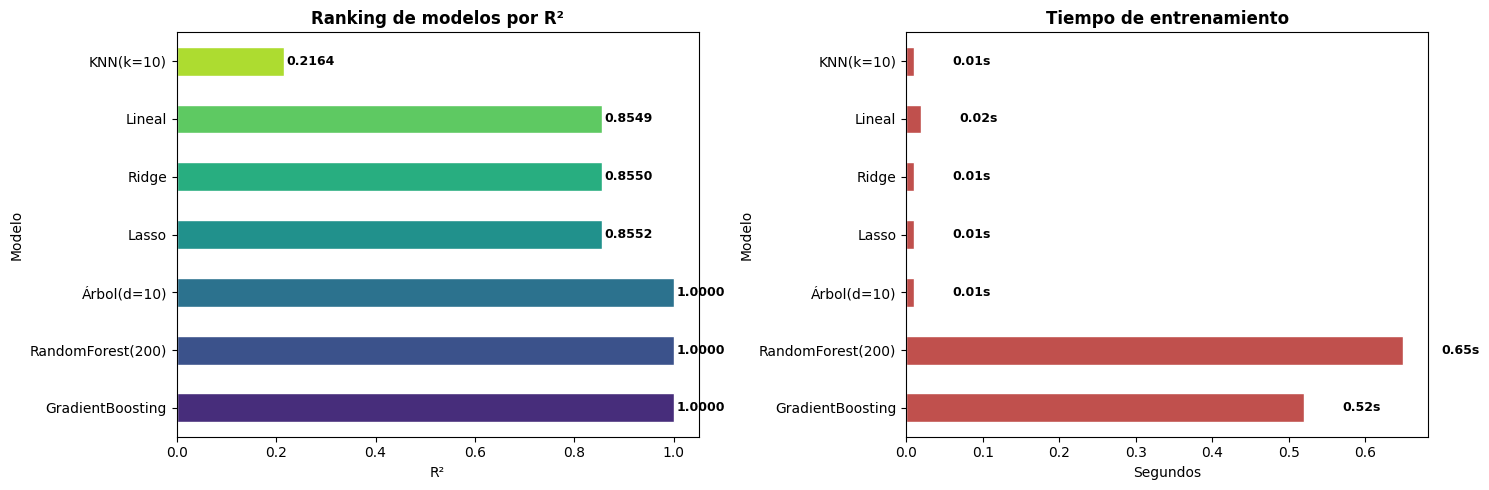

💡 No solo importa el R² — también el tiempo. En producción, un modelo
   que tarda 100x más por 1% más de R² puede no valer la pena.


In [ ]:
# Visualización del benchmark
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² por modelo
colores = sns.color_palette('viridis', len(tabla))
tabla['R²'].plot(kind='barh', ax=axes[0], color=colores, edgecolor='white')
for i, v in enumerate(tabla['R²']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('R²')
axes[0].set_title('Ranking de modelos por R²', fontweight='bold')

# Tiempo de entrenamiento
tabla['Tiempo fit (s)'].plot(kind='barh', ax=axes[1], color='#C0504D', edgecolor='white')
for i, v in enumerate(tabla['Tiempo fit (s)']):
    axes[1].text(v + 0.05, i, f'{v}s', va='center', fontweight='bold', fontsize=9)
axes[1].set_xlabel('Segundos')
axes[1].set_title('Tiempo de entrenamiento', fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 No solo importa el R² — también el tiempo. En producción, un modelo')
print('   que tarda 100x más por 1% más de R² puede no valer la pena.')

Selección del mejor modelo y tueno

In [ ]:
# El ganador es: Lasso → lo tuneamos.
# Pipeline completo: preprocesador + Lasso. GridSearch optimiza alpha dentro del pipeline.
pipe_lasso = Pipeline([
    ('preprocesador', preprocesador),
    ('modelo',  Lasso(max_iter=10000))
])

# 'modelo__alpha' accede al alpha del Lasso dentro del pipeline.
# alpha controla la fuerza de la regularización (más alto = más features eliminadas)
param_grid = {
    'modelo__alpha': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0]
}

grid = GridSearchCV(
    pipe_lasso, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

mejor_alpha = grid.best_params_['modelo__alpha']
print(f'\n🏆 Mejor alpha:              {mejor_alpha}')
print(f'   Mejor R² (CV en train):  {grid.best_score_:.4f}')
print(f'   R² en TEST:              {grid.score(X_test, y_test):.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

🏆 Mejor alpha:              3.0
   Mejor R² (CV en train):  0.8508
   R² en TEST:              0.8564


N/A
Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.


## Parte 4: Análisis de Métricas

1. Informe de Clasificación:
* Generar un informe de clasificación para los modelos evaluados.
* Incluir la matriz de confusión para una comprensión detallada de los errores de clasificación.
2. Curva ROC y AUC:
* Crear y visualizar la curva ROC para los modelos de clasificación binaria.
* Calcular el AUC para evaluar la capacidad del modelo para distinguir entre clases.

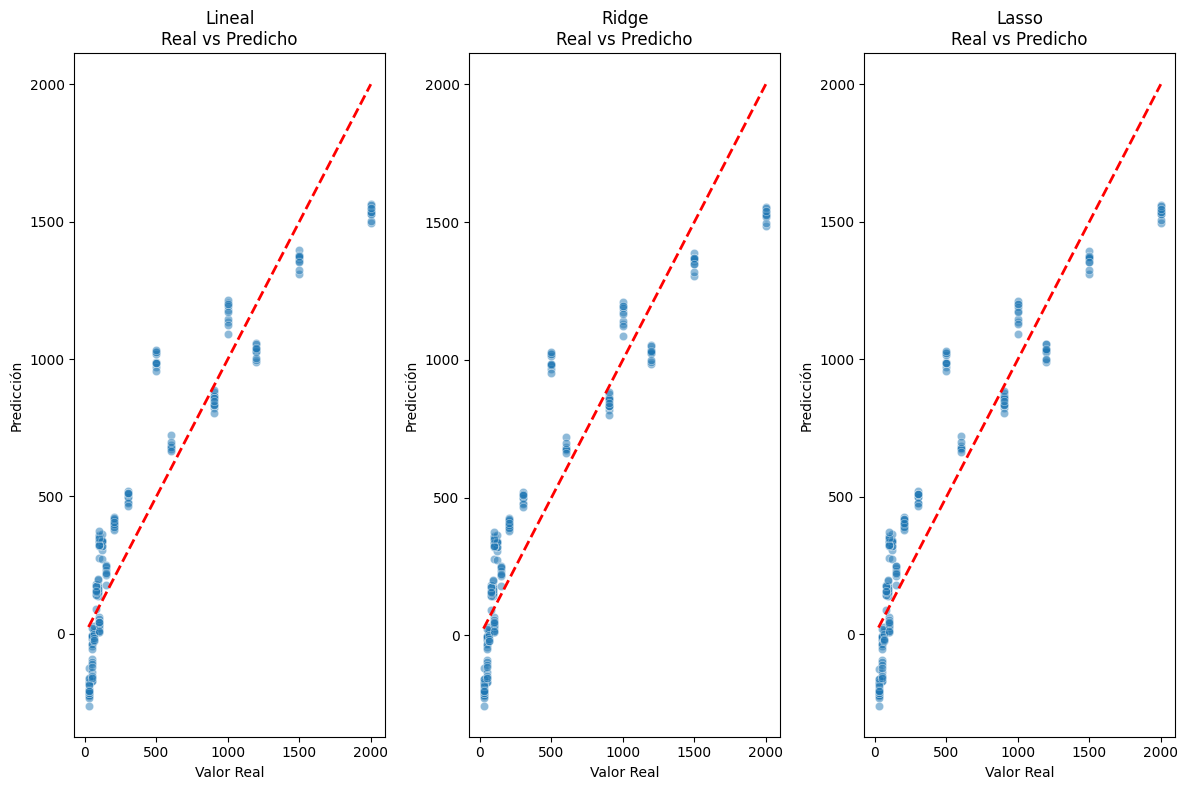

Para 'Total Amount' (regresión), usamos gráficos de dispersión y métricas como MAE y R².


In [ ]:
# En regresión no usamos matrices de confusión, usamos gráficos de dispersión reales vs predichos
plt.figure(figsize=(12, 8))

# Graficamos las predicciones del mejor modelo
# Tomaremos el modelo Lasso que tuneamos previamente
for i, (nombre, m) in enumerate(list(modelos.items())[:3]): # Mostramos los 3 primeros para no saturar
    y_pred_model = m.predict(X_test)

    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=y_test, y=y_pred_model, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'{nombre}\nReal vs Predicho')
    plt.xlabel('Valor Real')
    plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

print("Para 'Total Amount' (regresión), usamos gráficos de dispersión y métricas como MAE y R².")

#### 2. Valores Reales vs. Predichos (Lasso/Ridge)
*   **¿Qué buscar?:** Los puntos deben estar lo más cerca posible de la **línea roja punteada**.
*   **Interpretación:** Verás que los puntos se agrupan en 'bloques' horizontales. Esto sucede porque el `Total Amount` es discreto (ej. 3 unidades x 50 USD = 150 exactos). El modelo Lasso es muy preciso para captar estos saltos, lo que explica su alto R² (~0.86).
